# A 1 um margin on the filled template: `hem_rect_fill_1um` vs. `hem_rect_fill` and `default_51` -- `chromatin_od`, 49 ROIs x 3 clicks

**Question.** `hem_rect_fill_vs_default_chromatin_od_49roi_3seed.ipynb` kept the pixels inside the hematoxylin Otsu
rectangle and flattened everything else to its mean. That rectangle is the Otsu component's own bounding box, so
the kept region ends exactly at the component's edge. This notebook widens the kept region by 1 um on every edge
and asks whether precision@K (K = 10, 20, 30) changes.

| arm | template pixels |
|---|---|
| `default_51` | the 51x51 `hematoxylin_od` window centred on the click, cut the way production cuts it |
| `hem_rect_fill` | the same array; pixels outside the hematoxylin Otsu rectangle are set to their own mean (re-run of the recorded arm) |
| `hem_rect_fill_1um` | the same array; the rectangle is first grown by `round(1 um / mpp)` px on every edge, each edge clipped to the 51 px window on its own; pixels outside the grown rectangle are set to their own mean |

The margin is a larger kept crop, not added values. Pixels in the margin keep their original values. The template
stays 51x51 and centred on the click, and nothing outside that window is read. At these ROIs' 0.226-0.253 um/px,
1 um rounds to 4 px on every ROI. An edge with less than 4 px of room grows only as far as the window border, and
the other edges still grow by the full margin.

**Identical in all three arms.** Only the template's pixel values differ. These are the same:
- window position (centred on the click) and template size (51 px);
- search image (`hematoxylin_od`, replicate-padded by 25 px);
- peak, NMS and self-hit settings (`PEAK_MIN_DISTANCE` 7, `DEEP_FLOOR_Z` -1.5, `MAX_PEAKS` 100, NMS radius = match
  radius = 7.5 um, `SELF_HIT_RADIUS` 5 px), with the self-hit centre at the click;
- the `chromatin_od` window (51 px);
- scoring (greedy centre-distance match at 7.5 um, with the click's own annotation removed from the ground truth);
- the 147 clicks, inherited from the 49-ROI joint gate.

**Reproduction gates.** `default_51` must reproduce the recorded bbox3way run, and `hem_rect_fill` must reproduce
the recorded hemrectfill run, on every click before the new arm runs. Both runs are recorded in `results/`.

**Comparisons.** Every delta is `a - b`. ROI is the unit: for each ROI and K, the delta is TP@K summed over the ROI's 3 clicks.
- **A: `hem_rect_fill_1um - default_51`.** Does the margin version differ from production's template?
- **B: `hem_rect_fill_1um - hem_rect_fill`.** Does adding the margin change precision relative to the tight crop?
- **Reproduction: `hem_rect_fill - default_51`.** Not a new claim. Its per-ROI deltas and statistics must equal the recorded hemrectfill run exactly.

Per pair and K: the pooled precision delta with a cluster-bootstrap 95% CI over ROIs (same bootstrap indices as the
hemrectfill run), a t interval over the ROI-level deltas, ROI-level W/L/T, an exact sign-flip p with Holm over the
6 tests of A and B, and the D5 bar (bootstrap CI excludes 0 and a majority of all ROIs move in the delta's direction).

**Reading rules, fixed before the run.** They are applied to the bootstrap CI of each A and B delta at each K.
- **Bootstrap CI excludes 0, delta < 0:** `a` has lower precision than `b`.
- **Bootstrap CI excludes 0, delta > 0:** `a` has higher precision than `b`.
- **CI includes 0:** no difference detected. The CI is quoted as the bound. No equivalence is claimed.

Each verdict is stated together with its t CI, exact p, Holm p, ROI W/L/T and D5 bar. A CI that excludes 0 is
reported with those numbers alongside, never on its own.

**Caveats.**
- `chromatin_od` ranking only.
- The clicks are inherited from the 49-ROI joint gate.
- One margin (1 um, 4 px here) and one fill rule (the mean of the pixels outside the kept rectangle).
- The margin grows the Otsu rectangle, not the component, and is clipped at the 51 px window.
- Each arm's peak threshold comes from its own response map, so the arms' candidate lists can differ in length.
  Precision is compared at fixed K.
- Power. In the hemrectfill run, `hem_rect_fill - default_51` was at most about 1 point, with bootstrap CIs about
  2.5 points wide. The margin arm's pixels lie between those two arms, so differences smaller than those CIs can
  resolve are a likely outcome.

In [1]:
import gc
import hashlib
import itertools
import math
import os
import sys
import time
from fractions import Fraction

import cv2
import numpy as np
import pandas as pd
from scipy import stats as sps
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import chromatin as cm
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import invariants as inv
from midog_utils import production as prod
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 400)
pd.set_option('display.max_colwidth', 140)

NB_T0 = time.time()

# The production settings are read from midog_utils.production, then checked against the values the 14-ROI notebook ran with.
REFERENCE_CONFIG = dict(CHANNEL='hematoxylin_od', TM_METHOD=cv2.TM_CCOEFF, PEAK_MIN_DISTANCE=7, SELF_HIT_RADIUS=5.0, DEEP_FLOOR_Z=-1.5, MAX_PEAKS=100, OD_WINDOW=51)
CONFIG_DRIFT = pd.DataFrame([dict(setting=k, production_py=getattr(prod, k), reference_notebook=v, match=getattr(prod, k) == v) for k, v in REFERENCE_CONFIG.items()])
print(CONFIG_DRIFT.to_string(index=False))
assert CONFIG_DRIFT['match'].all(), 'midog_utils.production no longer matches the configuration the 14-ROI notebook ran at'
assert ev.MIDOG_RADIUS_UM == 7.5, 'D7: NMS radius = match radius = 7.5 um'
assert tm.BASE_SIZE == 51, 'the template size this notebook hard-codes is 51 px'
assert tm.PATCH_SIZE == 73, 'the rotation-safe patch this notebook hard-codes is 73 px'
assert prod.OD_WINDOW // 2 == 25, 'the replicate pad this notebook hard-codes is 25 px'

SMOKE_ROIS = None  # None = all 49 ROIs; a smoke run names ROIs that cover both an unclipped and a clipped margin
MARGIN_UM = 1.0
ARMS = ('default_51', 'hem_rect_fill', 'hem_rect_fill_1um')
NEW_PAIRS = (('hem_rect_fill_1um', 'default_51'), ('hem_rect_fill_1um', 'hem_rect_fill'))
REPRO_PAIR = ('hem_rect_fill', 'default_51')
PAIRS = NEW_PAIRS + (REPRO_PAIR,)  # every delta is a - b
BUDGETS = (10, 20, 30)
SEED_INDICES = (0, 1, 2)
N_BOOT = 10_000
BOOT_SEED = 20260917  # the hemrectfill run's seed, so the reproduction pair's CIs must match it exactly
B3 = '../results/precision_at_k_49roi_3seed_chromatin_bbox3way'
HRF = '../results/precision_at_k_49roi_3seed_chromatin_hemrectfill'
SUBSET_DIRS = {'original_14': '../images/extra_valid', 'testing_35': '../images/extra_valid/testing_set'}
INSPECT_ROI = '300.tiff'  # the ROI whose three clicks were inspected by eye before this run

OUT_STEM = '../results/precision_at_k_49roi_3seed_chromatin_hemrectfill1um' + ('' if SMOKE_ROIS is None else '_smoke')
OUT = {name: f'{OUT_STEM}_{name}.csv' for name in ('clicks', 'per_run', 'top30', 'per_roi', 'delta_per_roi', 'delta_stats', 'verification')}
FIG_PATHS = {'overview': 'hemrectfill1um_49roi3seed_templates.png', 'inspect_roi': 'hemrectfill1um_300_templates.png', 'clipped': 'hemrectfill1um_clipped_edge_templates.png'}
assert not any(p.startswith(B3 + '_') or p.startswith(HRF + '_') or p.startswith('../results/precision_at_k_14roi_') for p in OUT.values()), 'an output path would overwrite a recorded run'

print(f"\narms {ARMS}; pairs {[f'{a} - {b}' for a, b in PAIRS]}; margin {MARGIN_UM} um; K = {BUDGETS}; cluster bootstrap B = {N_BOOT} (seed {BOOT_SEED}); smoke ROIs = {SMOKE_ROIS}")
print('outputs:', *OUT.values(), *FIG_PATHS.values(), sep='\n  ')

          setting  production_py reference_notebook  match
          CHANNEL hematoxylin_od     hematoxylin_od   True
        TM_METHOD              4                  4   True
PEAK_MIN_DISTANCE              7                  7   True
  SELF_HIT_RADIUS            5.0                5.0   True
     DEEP_FLOOR_Z           -1.5               -1.5   True
        MAX_PEAKS            100                100   True
        OD_WINDOW             51                 51   True

arms ('default_51', 'hem_rect_fill', 'hem_rect_fill_1um'); pairs ['hem_rect_fill_1um - default_51', 'hem_rect_fill_1um - hem_rect_fill', 'hem_rect_fill - default_51']; margin 1.0 um; K = (10, 20, 30); cluster bootstrap B = 10000 (seed 20260917); smoke ROIs = None
outputs:
  ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill1um_clicks.csv
  ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill1um_per_run.csv
  ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill1um_top30.csv
  ../results/precision_at_

In [2]:
B3_RUN = pd.read_csv(f'{B3}_per_run.csv', float_precision='round_trip')
B3_TOP = pd.read_csv(f'{B3}_top30.csv', float_precision='round_trip')
HRF_RUN = pd.read_csv(f'{HRF}_per_run.csv', float_precision='round_trip')
HRF_TOP = pd.read_csv(f'{HRF}_top30.csv', float_precision='round_trip')
HRF_CLICKS = pd.read_csv(f'{HRF}_clicks.csv', float_precision='round_trip')
HRF_DELTA = pd.read_csv(f'{HRF}_delta_per_roi.csv', float_precision='round_trip')
HRF_STATS = pd.read_csv(f'{HRF}_delta_stats.csv', float_precision='round_trip')
assert (len(B3_RUN), len(HRF_RUN), len(HRF_TOP), len(HRF_CLICKS), len(HRF_DELTA), len(HRF_STATS)) == (441, 294, 8820, 147, 147, 3), 'a recorded input does not have its expected row count'

# the recorded run each re-run arm must reproduce: default_51 from bbox3way, hem_rect_fill from hemrectfill
REF_RUN = pd.concat([B3_RUN[B3_RUN['condition'] == 'default_51'], HRF_RUN[HRF_RUN['condition'] == 'hem_rect_fill']]).set_index(['file_name', 'seed_index', 'condition']).sort_index()
REF_TOP = {key: g for key, g in pd.concat([B3_TOP[B3_TOP['condition'] == 'default_51'], HRF_TOP[HRF_TOP['condition'] == 'hem_rect_fill']]).groupby(['file_name', 'seed_index', 'condition'])}
assert REF_RUN.index.is_unique and len(REF_RUN) == 294, 'recorded reference runs are not one row per click per re-run arm'
assert len(REF_TOP) == 294 and all(len(g) == 30 for g in REF_TOP.values()), 'recorded reference top-30 lists are not 30 rows per click per re-run arm'

# the clicks: the recorded bbox3way default_51 rows, in CSV row order; the hemrectfill run used the same clicks in the same order
CLICKS = B3_RUN[B3_RUN['condition'] == 'default_51'].reset_index(drop=True)
assert CLICKS[['file_name', 'seed_index', 'seed_ann_id']].equals(HRF_RUN.loc[HRF_RUN['condition'] == 'default_51', ['file_name', 'seed_index', 'seed_ann_id']].reset_index(drop=True)), 'the hemrectfill run did not use the bbox3way clicks in the same order'
assert CLICKS[['file_name', 'seed_index', 'seed_ann_id']].equals(HRF_CLICKS[['file_name', 'seed_index', 'seed_ann_id']]), 'the hemrectfill clicks table is not in click order'
ROI_ORDER = [fn for fn in pd.unique(CLICKS['file_name']) if SMOKE_ROIS is None or fn in SMOKE_ROIS]
assert SMOKE_ROIS is None or sorted(ROI_ORDER) == sorted(SMOKE_ROIS), f'smoke ROIs not found: {SMOKE_ROIS}'
N_ROIS = len(ROI_ORDER)
CLICKS = CLICKS[CLICKS['file_name'].isin(ROI_ORDER)].reset_index(drop=True)
click_keys = list(zip(CLICKS['file_name'], CLICKS['seed_index']))

# recorded geometry: the hem_bbox template spec (bbox3way) and the hem_rect_fill rectangle and fill value (hemrectfill)
hem_rec = B3_RUN.loc[B3_RUN['condition'] == 'hem_bbox', ['file_name', 'seed_index', 'base_size', 'tpl_cx', 'tpl_cy']].rename(columns={'base_size': 'rec_hem_base', 'tpl_cx': 'rec_hem_cx', 'tpl_cy': 'rec_hem_cy'})
rect_rec = HRF_CLICKS[['file_name', 'seed_index', 'rect_y0', 'rect_y1', 'rect_x0', 'rect_x1', 'fill_value']].rename(columns={'rect_y0': 'rec_y0', 'rect_y1': 'rec_y1', 'rect_x0': 'rec_x0', 'rect_x1': 'rec_x1', 'fill_value': 'rec_fill_value'})
CLICKS = CLICKS.merge(hem_rec, on=['file_name', 'seed_index'], how='left', validate='one_to_one').merge(rect_rec, on=['file_name', 'seed_index'], how='left', validate='one_to_one')
assert list(zip(CLICKS['file_name'], CLICKS['seed_index'])) == click_keys, 'a merge changed the click rows or their order'
assert CLICKS[['rec_hem_base', 'rec_hem_cx', 'rec_hem_cy', 'rec_y0', 'rec_y1', 'rec_x0', 'rec_x1', 'rec_fill_value']].notna().all().all(), 'a click has no recorded geometry'

images, annotations = ds.load_annotations('../databases/MIDOG++.json')
for r in CLICKS.itertuples():
    match = annotations[(annotations['ann_id'] == r.seed_ann_id) & (annotations['file_name'] == r.file_name)]
    assert len(match) == 1, f'{r.file_name} s{r.seed_index}: {len(match)} annotation rows for ann_id {r.seed_ann_id}'
    assert match['category_id'].iat[0] == ds.MITOTIC and match['cx'].iat[0] == r.click_cx and match['cy'].iat[0] == r.click_cy, f'{r.file_name} s{r.seed_index}: ann_id {r.seed_ann_id} is not a mitotic figure at the recorded click'
assert len(CLICKS) == 3 * N_ROIS, f'{len(CLICKS)} clicks, expected {3 * N_ROIS}'
assert SMOKE_ROIS is not None or N_ROIS == 49, f'full run has {N_ROIS} ROIs, expected 49'

print(f"{len(CLICKS)} clicks on {N_ROIS} ROIs {ROI_ORDER if SMOKE_ROIS is not None else ''}; every seed_ann_id is a mitotic annotation at its recorded click")
print(f"recorded references: {len(REF_RUN)} runs and {len(REF_TOP)} top-30 lists (default_51 from bbox3way, hem_rect_fill from hemrectfill); hemrectfill clicks match bbox3way clicks and order")

147 clicks on 49 ROIs ; every seed_ann_id is a mitotic annotation at its recorded click
recorded references: 294 runs and 294 top-30 lists (default_51 from bbox3way, hem_rect_fill from hemrectfill); hemrectfill clicks match bbox3way clicks and order


In [3]:
def margin_rect(rect, margin_px):
    """
        A half-open template-local rectangle grown by margin_px on every edge, each edge clipped to the 51 px window on its own.

        rect (tuple[int, int, int, int]): (y0, y1, x0, x1), half-open, template-local.
        margin_px (int): pixels added on every edge before clipping.

        Returns tuple[int, int, int, int]: the grown rectangle (y0, y1, x0, x1), inside [0, 51].
    """
    y0, y1, x0, x1 = rect
    return max(0, y0 - margin_px), min(51, y1 + margin_px), max(0, x0 - margin_px), min(51, x1 + margin_px)


def fill_outside(T, rect):
    """
        The template with every pixel outside a rectangle set to the mean of those pixels.

        T (np.ndarray): the 51x51 float32 template.
        rect (tuple[int, int, int, int]): the kept rectangle (y0, y1, x0, x1), half-open, template-local.

        Returns tuple[np.ndarray, np.float32, int]: the filled template, the fill value, and the number of filled pixels.
    """
    y0, y1, x0, x1 = rect
    outside = np.ones((51, 51), bool)
    outside[y0:y1, x0:x1] = False
    assert outside.any(), f'rectangle {rect} covers the whole window, so nothing is filled'
    fill = np.float32(T[outside].astype(np.float64).mean())
    F = T.copy()
    F[outside] = fill
    assert F.dtype == np.float32 and F.flags['C_CONTIGUOUS'], f'rectangle {rect}: filled template is {F.dtype}, contiguous={F.flags["C_CONTIGUOUS"]}'
    assert np.array_equal(F[y0:y1, x0:x1], T[y0:y1, x0:x1]) and (F[outside] == fill).all(), f'rectangle {rect}: the fill changed a kept pixel or missed a filled one'
    return F, fill, int(outside.sum())


def cut_templates(hem, cx, cy, margin_px):
    """
        The three templates for one click: the default 51 px window, and that window filled outside the hematoxylin Otsu rectangle and outside the rectangle grown by margin_px.

        hem (np.ndarray): this ROI's hematoxylin_od channel.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.
        margin_px (int): pixels added on every edge of the rectangle, each edge clipped to the window.

        Returns dict: T, F0, Fm (the three 51x51 float32 templates), rect and rect_m (half-open template-local rectangles), fill0, fillm (fill values), n0, nm (filled pixel counts).
    """
    patch = tm.read_padded_patch(hem, cx, cy, 73)
    assert patch is not None, f'({cx}, {cy}): the 73 px patch is not readable'
    templates, _ = tm.build_augmentations(patch, 51, (1.0,), 1, (False,))
    T = templates[0]
    assert T.shape == (51, 51) and T.dtype == np.float32, f'({cx}, {cy}): template is {T.shape} {T.dtype}'
    W = tm.read_padded_patch(hem, cx, cy, 51)
    assert np.array_equal(W, T), f'({cx}, {cy}): the Otsu window and the template are not the same pixels'
    rect = ss.tighten_box_otsu(W)
    assert rect is not None, f'({cx}, {cy}): tighten_box_otsu refused the window'
    rect_m = margin_rect(rect, margin_px)
    F0, fill0, n0 = fill_outside(T, rect)
    Fm, fillm, nm = fill_outside(T, rect_m)
    return dict(T=T, F0=F0, Fm=Fm, rect=rect, rect_m=rect_m, fill0=fill0, fillm=fillm, n0=n0, nm=nm)


def run_template(hem_padded, shape, template, cx, cy, mpp):
    """
        Search one 51 px template over the ROI and rank its candidates by chromatin_od, in the order find_and_suppress and run_production_pipeline(rank_key='chromatin_od') apply each step.

        hem_padded (np.ndarray): this ROI's hematoxylin_od channel, replicate-padded by 25 px on every side.
        shape (tuple): the unpadded channel's (height, width).
        template (np.ndarray): the 51x51 float32 template.
        cx (float): click x, the self-hit centre.
        cy (float): click y, the self-hit centre.
        mpp (float): the ROI's microns per pixel.

        Returns tuple[pd.DataFrame, dict]: detections ranked by od (rank, cx, cy, score, od), and the counts n_peaks, n_detections, n_self_hits.
    """
    nms_radius = ev.radius_px(mpp)
    inv.check_nms_radius(nms_radius, mpp, label='hem_rect_fill_1um')
    pad = 25
    h, w = shape
    fused_p, best_p, valid_p = tm.fused_response(hem_padded, [template], False, method=prod.TM_METHOD)
    fused = fused_p[pad:pad + h, pad:pad + w]
    valid = valid_p[pad:pad + h, pad:pad + w]
    assert valid.all(), 'the 25 px pad left part of the ROI unreachable'
    med, mad = tm.robust_stats(fused, valid)
    threshold = med + prod.DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, prod.PEAK_MIN_DISTANCE, threshold, prod.MAX_PEAKS)
    n_peaks = len(centers)
    keep = nms_by_distance(centers, scores, nms_radius)
    centers, scores = centers[keep], scores[keep]
    self_hit = np.hypot(centers[:, 0] - float(cx), centers[:, 1] - float(cy)) <= prod.SELF_HIT_RADIUS
    n_self_hits = int(self_hit.sum())
    centers, scores = centers[~self_hit], scores[~self_hit]
    det = pd.DataFrame({'rank': np.arange(len(centers)), 'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
    shifted = det.assign(cx=det['cx'] + 25, cy=det['cy'] + 25)
    det = det.assign(od=cm.score_detections(shifted, hem_padded, window=prod.OD_WINDOW)['od'].to_numpy())
    det = det.sort_values('od', ascending=False, na_position='last', kind='mergesort').reset_index(drop=True)
    det = det.assign(rank=np.arange(len(det)))
    return det, {'n_peaks': n_peaks, 'n_detections': len(det), 'n_self_hits': n_self_hits}


def score_top_k(detections, gt_eval, match_radius):
    """
        Match a ranked detection list to ground truth and count true positives in each top-K.

        detections (pd.DataFrame): ranked detections, best first.
        gt_eval (pd.DataFrame): ground truth with the click's own annotation removed.
        match_radius (float): match radius in pixels.

        Returns tuple[pd.DataFrame, dict]: the detections with match buckets added, and K -> true positives in the top K.
    """
    det_out, _ = ev.bucket_detections(detections, gt_eval, match_radius)
    hit = (det_out['bucket'] == ev.HUMAN_CORRECT_LABEL).to_numpy()
    return det_out, {k: int(hit[:k].sum()) for k in BUDGETS}


def parity_gate(tag, out, info, tp, ref_run, ref_top):
    """
        Assert that a re-run arm reproduces its recorded run, and count the top-30 od values that match bit for bit.

        tag (str): names the click and arm in assertion messages.
        out (pd.DataFrame): the re-run's scored detections, ranked.
        info (dict): the re-run's n_peaks, n_detections and n_self_hits.
        tp (dict): the re-run's K -> true positives.
        ref_run (pd.Series): the recorded per_run row for this click and arm.
        ref_top (pd.DataFrame): the recorded top-30 rows for this click and arm.

        Returns int: the number of top-30 od values equal to the recorded ones bit for bit.
    """
    ref_top = ref_top.sort_values('rank')
    top = out.head(30)
    assert (info['n_peaks'], info['n_detections'], info['n_self_hits']) == (ref_run['n_peaks'], ref_run['n_detections'], ref_run['n_self_hits']), f"{tag}: (n_peaks, n_detections, n_self_hits) {(info['n_peaks'], info['n_detections'], info['n_self_hits'])} != recorded {(ref_run['n_peaks'], ref_run['n_detections'], ref_run['n_self_hits'])}"
    assert all(tp[k] == ref_run[f'tp_at_{k}'] for k in BUDGETS), f"{tag}: TP@K {tp} != recorded {[ref_run[f'tp_at_{k}'] for k in BUDGETS]}"
    assert len(ref_top) == 30, f'{tag}: {len(ref_top)} recorded top-30 rows'
    for c in ('rank', 'cx', 'cy', 'bucket', 'matched_ann_id'):
        assert np.array_equal(top[c].to_numpy(), ref_top[c].to_numpy()), f'{tag}: top-30 {c} differs from the recorded list'
    assert np.array_equal(top['score'].to_numpy(), ref_top['score'].to_numpy().astype(np.float32)), f'{tag}: top-30 float32 score differs from the recorded list'
    assert np.isclose(top['od'].to_numpy(), ref_top['od'].to_numpy(), rtol=1e-12, atol=0).all(), f'{tag}: top-30 od differs from the recorded list beyond rtol 1e-12'
    return int((top['od'].to_numpy() == ref_top['od'].to_numpy()).sum())

In [4]:
per_run_rows, click_rows, top_frames = [], [], []
TEMPLATES = {}
n_parity = {'default_51': 0, 'hem_rect_fill': 0}
n_od_bit_exact_total = {'default_51': 0, 'hem_rect_fill': 0}
t_loop = time.time()
for i, file_name in enumerate(ROI_ORDER):
    rows = CLICKS[CLICKS['file_name'] == file_name].sort_values('seed_index')
    assert rows['seed_index'].tolist() == list(SEED_INDICES), f'{file_name}: seed indices {rows["seed_index"].tolist()}'

    # load
    path = f"{SUBSET_DIRS[rows['subset'].iat[0]]}/{file_name}"
    assert os.path.exists(path), f'{path} does not exist'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    assert mpp == rows['mpp'].iat[0], f"{file_name}: mpp {mpp!r} != recorded {rows['mpp'].iat[0]!r}"
    margin_px = int(round(MARGIN_UM / mpp))
    assert margin_px >= 1, f'{file_name}: a {MARGIN_UM} um margin rounds to {margin_px} px'

    # prepare
    hem = ch.to_channel(rgb, 'hematoxylin_od')
    hem_padded = cv2.copyMakeBorder(hem, 25, 25, 25, 25, borderType=cv2.BORDER_REPLICATE)
    gt = ds.image_annotations(annotations, file_name)
    match_radius = ev.radius_px(mpp)
    assert match_radius == rows['match_radius_px'].iat[0], f"{file_name}: match radius {match_radius!r} != recorded {rows['match_radius_px'].iat[0]!r}"

    progress = []
    for _, r in rows.iterrows():
        cx = float(r.click_cx)
        cy = float(r.click_cy)
        s = int(r.seed_index)
        tag = f'{file_name} s{s}'

        # templates, checked against both recorded runs
        cut = cut_templates(hem, cx, cy, margin_px)
        (y0, y1, x0, x1), (my0, my1, mx0, mx1) = cut['rect'], cut['rect_m']
        assert ss.tightened_template_box(hem, cx, cy) == (r.rec_hem_base, r.rec_hem_cx, r.rec_hem_cy), f'{tag}: the rectangle is not the one hem_bbox used'
        assert cut['rect'] == (r.rec_y0, r.rec_y1, r.rec_x0, r.rec_x1) and float(cut['fill0']) == r.rec_fill_value, f"{tag}: rectangle {cut['rect']} or fill {float(cut['fill0'])!r} differs from the hemrectfill run"
        sha = {'default_51': hashlib.sha1(cut['T'].tobytes()).hexdigest(), 'hem_rect_fill': hashlib.sha1(cut['F0'].tobytes()).hexdigest(), 'hem_rect_fill_1um': hashlib.sha1(cut['Fm'].tobytes()).hexdigest()}
        for arm in ('default_51', 'hem_rect_fill'):
            assert sha[arm] == REF_RUN.loc[(file_name, s, arm), 'tpl_sha1'], f'{tag}: {arm} template differs from the recorded one'
        assert len(set(sha.values())) == 3, f'{tag}: two arms have identical templates'

        # ground truth
        gt_eval = gt[gt['ann_id'] != r.seed_ann_id].reset_index(drop=True)
        assert int((gt_eval['category_id'] == ds.MITOTIC).sum()) == r.n_gt_mitotic, f'{tag}: mitotic ground-truth count differs from the recorded run'

        # the three arms; the two re-run arms must reproduce their recorded runs before the margin arm runs
        results = {}
        for arm, template in (('default_51', cut['T']), ('hem_rect_fill', cut['F0']), ('hem_rect_fill_1um', cut['Fm'])):
            t0 = time.time()
            det, info = run_template(hem_padded, hem.shape, template, cx, cy, mpp)
            out, tp = score_top_k(det, gt_eval, match_radius)
            t_run = time.time() - t0
            bit_exact = np.nan
            if arm in n_parity:
                bit_exact = parity_gate(f'{tag} {arm}', out, info, tp, REF_RUN.loc[(file_name, s, arm)], REF_TOP[(file_name, s, arm)])
                n_parity[arm] += 1
                n_od_bit_exact_total[arm] += bit_exact
            results[arm] = (out, info, tp, t_run, bit_exact)

        # per_run and top30 rows, one per arm
        for arm, (out, info, tp, t_run, bit_exact) in results.items():
            d_click = np.hypot(out['cx'].to_numpy() - cx, out['cy'].to_numpy() - cy)
            near = np.flatnonzero(d_click <= match_radius)
            near_detail = ';'.join(f"rank{int(out['rank'].iat[j])}:{out['bucket'].iat[j]}:ann{int(out['matched_ann_id'].iat[j])}:d_click={d_click[j]:.1f}" for j in near)
            per_run_rows.append(dict(subset=r.subset, domain=r.domain, file_name=file_name, image_id=int(r.image_id), seed_index=s, condition=arm, seed_ann_id=int(r.seed_ann_id), click_cx=cx, click_cy=cy, mpp=mpp, match_radius_px=match_radius, margin_px=margin_px, n_gt_mitotic=int(r.n_gt_mitotic), tpl_sha1=sha[arm], n_peaks=int(info['n_peaks']), n_detections=int(info['n_detections']), n_self_hits=int(info['n_self_hits']), n_near_click=len(near), near_click_detail=near_detail, od_nan=int(out['od'].isna().sum()), od_descending=bool(np.all(np.diff(out['od'].to_numpy()) <= 0)), t_run_s=round(t_run, 3), **{f'tp_at_{k}': tp[k] for k in BUDGETS}, n_od_bit_exact=bit_exact))
            top_frames.append(out.head(30)[['rank', 'cx', 'cy', 'score', 'od', 'bucket', 'matched_ann_id', 'matched_category']].assign(file_name=file_name, seed_index=s, condition=arm))

        # clicks row
        click_rows.append(dict(file_name=file_name, seed_index=s, seed_ann_id=int(r.seed_ann_id), margin_px=margin_px, rect_y0=y0, rect_y1=y1, rect_x0=x0, rect_x1=x1, rect_h=y1 - y0, rect_w=x1 - x0, rectm_y0=my0, rectm_y1=my1, rectm_x0=mx0, rectm_x1=mx1, rectm_h=my1 - my0, rectm_w=mx1 - mx0, grow_top=y0 - my0, grow_bottom=my1 - y1, grow_left=x0 - mx0, grow_right=mx1 - x1, n_filled_px=cut['n0'], filled_share=cut['n0'] / 2601, fill_value=float(cut['fill0']), n_filled_px_1um=cut['nm'], filled_share_1um=cut['nm'] / 2601, fill_value_1um=float(cut['fillm']), tpl_mean_default=float(cut['T'].astype(np.float64).mean()), tpl_mean_filled=float(cut['F0'].astype(np.float64).mean()), tpl_mean_filled_1um=float(cut['Fm'].astype(np.float64).mean())))
        TEMPLATES[(file_name, s)] = cut
        progress.append(f"s{s} rect {y1 - y0}x{x1 - x0}->{my1 - my0}x{mx1 - mx0} tp d={tuple(results['default_51'][2].values())} f={tuple(results['hem_rect_fill'][2].values())} f1um={tuple(results['hem_rect_fill_1um'][2].values())}")

    # persist and free
    pd.DataFrame(click_rows).to_csv(OUT['clicks'], index=False)
    pd.DataFrame(per_run_rows).to_csv(OUT['per_run'], index=False)
    pd.concat(top_frames, ignore_index=True).to_csv(OUT['top30'], index=False)
    del rgb, hem, hem_padded
    gc.collect()
    print(f"[{i + 1}/{N_ROIS} {file_name}] margin {margin_px} px, {(time.time() - t_loop) / 60:.1f} min | " + ' | '.join(progress), flush=True)

PER_RUN = pd.DataFrame(per_run_rows)
CLICK_TABLE = pd.DataFrame(click_rows)
TOP = pd.concat(top_frames, ignore_index=True)
RUNTIME_LOOP_MIN = (time.time() - t_loop) / 60
for arm, rec in (('default_51', 'bbox3way'), ('hem_rect_fill', 'hemrectfill')):
    print(f"\nparity gate {arm}: {n_parity[arm]}/{len(CLICKS)} runs reproduce the recorded {rec} run (n_peaks, n_detections, n_self_hits, TP@{BUDGETS}, template sha1, top-30 rank/cx/cy/bucket/matched_ann_id/float32 score/od at rtol 1e-12); od bit-exact on {n_od_bit_exact_total[arm]}/{30 * n_parity[arm]} top-30 rows")
print(f"\nrun loop: {RUNTIME_LOOP_MIN:.1f} min for {N_ROIS} ROIs x {len(SEED_INDICES)} clicks x {len(ARMS)} arms = {len(PER_RUN)} template runs")
print(PER_RUN.groupby('condition', sort=False)['t_run_s'].agg(['count', 'sum', 'median', 'min', 'max']).round(2).to_string())

[1/49 300.tiff] margin 4 px, 1.1 min | s0 rect 25x13->33x21 tp d=(9, 19, 27) f=(9, 18, 26) f1um=(9, 18, 26) | s1 rect 14x21->22x29 tp d=(9, 19, 27) f=(9, 18, 26) f1um=(10, 19, 27) | s2 rect 21x25->29x33 tp d=(9, 18, 27) f=(9, 18, 27) f1um=(10, 19, 28)


[2/49 301.tiff] margin 4 px, 2.1 min | s0 rect 32x27->40x35 tp d=(8, 18, 26) f=(6, 15, 25) f1um=(6, 15, 24) | s1 rect 24x25->32x33 tp d=(8, 17, 26) f=(8, 17, 27) f1um=(8, 17, 27) | s2 rect 10x19->18x27 tp d=(6, 13, 21) f=(8, 18, 28) f1um=(9, 19, 29)


[3/49 322.tiff] margin 4 px, 3.0 min | s0 rect 24x24->32x32 tp d=(8, 14, 16) f=(8, 14, 16) f1um=(8, 14, 15) | s1 rect 29x16->37x24 tp d=(8, 13, 15) f=(8, 14, 16) f1um=(8, 14, 16) | s2 rect 27x16->35x24 tp d=(8, 14, 15) f=(8, 14, 16) f1um=(8, 14, 15)


[4/49 337.tiff] margin 4 px, 4.3 min | s0 rect 19x15->27x23 tp d=(8, 11, 12) f=(8, 11, 13) f1um=(8, 11, 14) | s1 rect 13x20->21x28 tp d=(8, 11, 13) f=(8, 11, 12) f1um=(8, 11, 12) | s2 rect 20x20->28x28 tp d=(8, 11, 13) f=(8, 11, 13) f1um=(8, 11, 13)


[5/49 339.tiff] margin 4 px, 5.3 min | s0 rect 24x31->32x39 tp d=(4, 5, 7) f=(4, 5, 7) f1um=(4, 5, 7) | s1 rect 31x25->39x33 tp d=(4, 5, 5) f=(5, 5, 5) f1um=(5, 5, 5) | s2 rect 8x19->16x27 tp d=(5, 6, 6) f=(5, 6, 6) f1um=(5, 6, 6)


...

[46/49 364.tiff] margin 4 px, 52.4 min | s0 rect 36x16->40x24 tp d=(5, 5, 5) f=(5, 5, 5) f1um=(5, 5, 5) | s1 rect 19x18->27x26 tp d=(6, 6, 6) f=(5, 5, 5) f1um=(5, 5, 5) | s2 rect 25x17->33x25 tp d=(5, 5, 5) f=(5, 5, 5) f1um=(5, 5, 5)


[47/49 400.tiff] margin 4 px, 53.0 min | s0 rect 22x31->30x39 tp d=(9, 17, 25) f=(9, 17, 25) f1um=(9, 17, 25) | s1 rect 30x27->38x35 tp d=(9, 17, 27) f=(9, 17, 27) f1um=(9, 17, 27) | s2 rect 29x33->37x41 tp d=(9, 17, 27) f=(9, 17, 26) f1um=(9, 17, 27)


[48/49 401.tiff] margin 4 px, 53.6 min | s0 rect 26x23->34x31 tp d=(7, 9, 10) f=(7, 9, 10) f1um=(7, 9, 10) | s1 rect 31x27->39x35 tp d=(7, 8, 8) f=(7, 8, 8) f1um=(7, 8, 8) | s2 rect 23x22->31x30 tp d=(7, 9, 10) f=(7, 9, 10) f1um=(7, 9, 10)


[49/49 404.tiff] margin 4 px, 54.1 min | s0 rect 39x32->47x40 tp d=(4, 8, 11) f=(4, 8, 11) f1um=(4, 8, 10) | s1 rect 27x31->35x39 tp d=(4, 7, 9) f=(4, 6, 9) f1um=(4, 7, 9) | s2 rect 40x27->48x35 tp d=(5, 8, 12) f=(5, 8, 12) f1um=(4, 7, 11)



parity gate default_51: 147/147 runs reproduce the recorded bbox3way run (n_peaks, n_detections, n_self_hits, TP@(10, 20, 30), template sha1, top-30 rank/cx/cy/bucket/matched_ann_id/float32 score/od at rtol 1e-12); od bit-exact on 4410/4410 top-30 rows

parity gate hem_rect_fill: 147/147 runs reproduce the recorded hemrectfill run (n_peaks, n_detections, n_self_hits, TP@(10, 20, 30), template sha1, top-30 rank/cx/cy/bucket/matched_ann_id/float32 score/od at rtol 1e-12); od bit-exact on 4410/4410 top-30 rows

run loop: 54.1 min for 49 ROIs x 3 clicks x 3 arms = 441 template runs
                   count     sum  median   min    max
condition                                            
default_51           147  799.75    4.38  1.73  24.65
hem_rect_fill        147  749.21    4.28  1.82  21.66
hem_rect_fill_1um    147  848.76    4.35  1.74  71.00


In [5]:
VKEY = ['file_name', 'seed_index', 'condition']


def verification_records(check, severity, frame, passed, detail=None):
    """
        One verification record per row of a frame.

        check (str): the check's name.
        severity (str): "halt" if a failure stops the notebook, "report" if it is recorded and the run continues.
        frame (pd.DataFrame): the rows the check was evaluated on, carrying whichever of file_name/seed_index/condition apply.
        passed (array-like): one bool (or NA, for a check with no pass criterion) per row of frame.
        detail (array-like or None): one diagnostic string per row, or None.

        Returns pd.DataFrame: check, severity, file_name, seed_index, condition, passed, detail.
    """
    out = pd.DataFrame({c: (frame[c].to_numpy() if c in frame else np.full(len(frame), 'ALL', dtype=object)) for c in VKEY})
    out.insert(0, 'severity', severity)
    out.insert(0, 'check', check)
    out['passed'] = pd.array(list(passed), dtype='boolean')
    out['detail'] = '' if detail is None else np.asarray(detail, dtype=object)
    return out


def arm_counts(frame, column):
    """
        A column's value counts within each arm.

        frame (pd.DataFrame): per_run rows with a condition column.
        column (str): the column to count.

        Returns list[str]: one "{value: count}" string per arm, in ARMS order.
    """
    return [str(frame.loc[frame['condition'] == arm, column].value_counts().sort_index().to_dict()) for arm in ARMS]


# halt: one row per arm per click, all carrying the same click
per_click = PER_RUN.groupby(['file_name', 'seed_index'], sort=False).agg(n_rows=('condition', 'size'), arms=('condition', lambda v: ';'.join(v)), n_seed_ann=('seed_ann_id', 'nunique'), n_gt_values=('n_gt_mitotic', 'nunique')).reset_index()
per_click['passed'] = (per_click['n_rows'] == len(ARMS)) & (per_click['arms'] == ';'.join(ARMS)) & (per_click['n_seed_ann'] == 1) & (per_click['n_gt_values'] == 1)
assert len(per_click) == len(CLICKS), f'{len(per_click)} (file_name, seed_index) groups, expected {len(CLICKS)}'

# halt: the margin geometry, recomputed from the recorded rectangle -- each edge grows by min(margin, room to the window border)
C = CLICK_TABLE
room = pd.DataFrame({'top': C['rect_y0'], 'bottom': 51 - C['rect_y1'], 'left': C['rect_x0'], 'right': 51 - C['rect_x1']})
grow = C[['grow_top', 'grow_bottom', 'grow_left', 'grow_right']].set_axis(room.columns, axis=1)
want = room.clip(upper=C['margin_px'], axis=0)
margin_ok = (grow == want).all(axis=1) & (C['n_filled_px_1um'] == 2601 - C['rectm_h'] * C['rectm_w']) & (C['n_filled_px'] == 2601 - C['rect_h'] * C['rect_w']) & (C['n_filled_px_1um'] >= 1) & (C['margin_px'] == np.rint(MARGIN_UM / PER_RUN.groupby(['file_name', 'seed_index'], sort=False)['mpp'].first().to_numpy()).astype(int))
clipped = (grow < C['margin_px'].to_numpy()[:, None]).any(axis=1)
mean_gap = pd.concat([(C['tpl_mean_filled'] - C['tpl_mean_default']).abs(), (C['tpl_mean_filled_1um'] - C['tpl_mean_default']).abs()], axis=1).max(axis=1)

bit_exact_frame = pd.DataFrame({'condition': ['default_51', 'hem_rect_fill']})
bit_exact_sums = [int(PER_RUN.loc[PER_RUN['condition'] == arm, 'n_od_bit_exact'].sum()) for arm in bit_exact_frame['condition']]

VERIF = pd.concat([
    verification_records('budget_delivered', 'halt', PER_RUN, PER_RUN['n_detections'] >= max(BUDGETS), 'n_detections=' + PER_RUN['n_detections'].astype(str)),
    verification_records('od_no_nan', 'halt', PER_RUN, PER_RUN['od_nan'] == 0),
    verification_records('od_descending', 'halt', PER_RUN, PER_RUN['od_descending']),
    verification_records('one_row_per_arm_same_click', 'halt', per_click, per_click['passed'], 'arms=' + per_click['arms'] + ' n_seed_ann=' + per_click['n_seed_ann'].astype(str) + ' n_gt_values=' + per_click['n_gt_values'].astype(str)),
    verification_records('margin_geometry', 'halt', C, margin_ok, [f'margin={m} room={tuple(rm)} grow={tuple(g)} filled_1um={n}' for m, rm, g, n in zip(C['margin_px'], room.itertuples(index=False), grow.itertuples(index=False), C['n_filled_px_1um'])]),
    verification_records('fills_keep_template_mean', 'halt', C, mean_gap <= 1e-6, [f'max |mean_filled - mean_default|={v:.3g}' for v in mean_gap]),
    verification_records('max_peaks_binds', 'report', PER_RUN, PER_RUN['n_peaks'] == prod.MAX_PEAKS, 'n_peaks=' + PER_RUN['n_peaks'].astype(str) + ' n_detections=' + PER_RUN['n_detections'].astype(str)),
    verification_records('seed_annulus_empty', 'report', PER_RUN, PER_RUN['n_near_click'] == 0, PER_RUN['near_click_detail']),
    verification_records('n_self_hits_value_counts', 'report', pd.DataFrame({'condition': list(ARMS)}), [pd.NA] * len(ARMS), arm_counts(PER_RUN, 'n_self_hits')),
    verification_records('margin_all_edges_grow_full', 'report', C, ~clipped, [f'grow={tuple(g)}' for g in grow.itertuples(index=False)]),
    verification_records('od_bit_exact_vs_recorded', 'report', bit_exact_frame, [v == 30 * len(CLICKS) for v in bit_exact_sums], [f'{v}/{30 * len(CLICKS)} top-30 od values bit-exact' for v in bit_exact_sums])
], ignore_index=True)
VERIF.to_csv(OUT['verification'], index=False)

print(VERIF.assign(passed=VERIF['passed'].eq(True).fillna(False).astype(int), failed=VERIF['passed'].eq(False).fillna(False).astype(int), no_criterion=VERIF['passed'].isna().astype(int), total=1).groupby(['severity', 'check'], sort=False)[['passed', 'failed', 'no_criterion', 'total']].sum().to_string())
print(f"\n[report] margin_px per click: {C['margin_px'].value_counts().sort_index().to_dict()}")
print(f"[report] clicks with at least one edge clipped at the window border: {int(clipped.sum())}/{len(C)}")
if clipped.any():
    print(C.loc[clipped, ['file_name', 'seed_index', 'rect_y0', 'rect_y1', 'rect_x0', 'rect_x1', 'rectm_y0', 'rectm_y1', 'rectm_x0', 'rectm_x1', 'grow_top', 'grow_bottom', 'grow_left', 'grow_right', 'n_filled_px_1um']].to_string(index=False))
print('[report] max_peaks_binds: n_peaks == 100 on ' + '; '.join(f"{arm} {int((PER_RUN.loc[PER_RUN['condition'] == arm, 'n_peaks'] == prod.MAX_PEAKS).sum())}/{int((PER_RUN['condition'] == arm).sum())}" for arm in ARMS))
under_cap = PER_RUN[PER_RUN['n_peaks'] != prod.MAX_PEAKS]
if len(under_cap):
    print(under_cap[VKEY + ['n_peaks', 'n_detections']].to_string(index=False))
print('[report] seed_annulus_empty: n_near_click == 0 on ' + '; '.join(f"{arm} {int((PER_RUN.loc[PER_RUN['condition'] == arm, 'n_near_click'] == 0).sum())}/{int((PER_RUN['condition'] == arm).sum())}" for arm in ARMS))
annulus = PER_RUN[PER_RUN['n_near_click'] > 0]
if len(annulus):
    print(annulus[VKEY + ['match_radius_px', 'n_near_click', 'near_click_detail']].to_string(index=False))
for arm, counts in zip(ARMS, arm_counts(PER_RUN, 'n_self_hits')):
    print(f'[report] n_self_hits value counts, {arm}: {counts}')
for arm, v in zip(bit_exact_frame['condition'], bit_exact_sums):
    print(f'[report] od bit-exact against the recorded {arm} top-30: {v}/{30 * len(CLICKS)}')
print('\nn_detections per arm: ' + '; '.join(f"{arm} min {PER_RUN.loc[PER_RUN['condition'] == arm, 'n_detections'].min()}, max {PER_RUN.loc[PER_RUN['condition'] == arm, 'n_detections'].max()}" for arm in ARMS))
n_det = PER_RUN.pivot(index=['file_name', 'seed_index'], columns='condition', values='n_detections')
for a, b in NEW_PAIRS:
    print(f"n_detections {a} - {b} per click: {(n_det[a] - n_det[b]).value_counts().sort_index().to_dict()}")
print(f"max |filled template mean - default template mean| over both fill arms = {mean_gap.max():.3g}")
print(f"-> {OUT['verification']}")

halt_failures = VERIF[(VERIF['severity'] == 'halt') & ~VERIF['passed'].fillna(False)]
assert halt_failures.empty, f"a halt check failed -- see {OUT['verification']}:\n{halt_failures.to_string(index=False)}"

                                     passed  failed  no_criterion  total
severity check                                                          
halt     budget_delivered               441       0             0    441
         od_no_nan                      441       0             0    441
         od_descending                  441       0             0    441
         one_row_per_arm_same_click     147       0             0    147
         margin_geometry                147       0             0    147
         fills_keep_template_mean       147       0             0    147
report   max_peaks_binds                441       0             0    441
         seed_annulus_empty             441       0             0    441
         n_self_hits_value_counts         0       0             3      3
         margin_all_edges_grow_full     132      15             0    147
         od_bit_exact_vs_recorded         2       0             0      2

[report] margin_px per click: {4: 147}
[report] cl

In [6]:
print(f'fill geometry over {len(CLICK_TABLE)} clicks (template-local pixels; filled share = filled pixels / 2601):')
geom = CLICK_TABLE[['rect_h', 'rect_w', 'filled_share', 'fill_value', 'rectm_h', 'rectm_w', 'filled_share_1um', 'fill_value_1um']].agg(['median', 'min', 'max']).T
print(geom.to_string(float_format=lambda v: f'{v:.4g}'))
touch = lambda p: (CLICK_TABLE[f'{p}_y0'] == 0) | (CLICK_TABLE[f'{p}_x0'] == 0) | (CLICK_TABLE[f'{p}_y1'] == 51) | (CLICK_TABLE[f'{p}_x1'] == 51)
print(f"\nkept rectangle touches the window edge: hem_rect_fill {int(touch('rect').sum())}/{len(CLICK_TABLE)}, hem_rect_fill_1um {int(touch('rectm').sum())}/{len(CLICK_TABLE)}")
print(f"filled share, hem_rect_fill_1um minus hem_rect_fill, per click: median {(CLICK_TABLE['filled_share_1um'] - CLICK_TABLE['filled_share']).median():.4f}, min {(CLICK_TABLE['filled_share_1um'] - CLICK_TABLE['filled_share']).min():.4f}, max {(CLICK_TABLE['filled_share_1um'] - CLICK_TABLE['filled_share']).max():.4f}")
print(f"clicks where hem_rect_fill_1um fills fewer than 100 px: {int((CLICK_TABLE['n_filled_px_1um'] < 100).sum())} ({';'.join(f'{f}/s{s}:{n}px' for f, s, n in CLICK_TABLE.loc[CLICK_TABLE['n_filled_px_1um'] < 100, ['file_name', 'seed_index', 'n_filled_px_1um']].values)})")

fill geometry over 147 clicks (template-local pixels; filled share = filled pixels / 2601):
                  median      min    max
rect_h                25        8     51
rect_w                26       12     51
filled_share      0.7735   0.1349 0.9416
fill_value       0.02818 0.004407 0.1071
rectm_h               33       16     51
rectm_w               34       20     51
filled_share_1um  0.5952  0.01961 0.8339
fill_value_1um   0.02777 0.003955 0.1086

kept rectangle touches the window edge: hem_rect_fill 9/147, hem_rect_fill_1um 20/147
filled share, hem_rect_fill_1um minus hem_rect_fill, per click: median -0.1753, min -0.2707, max -0.1015
clicks where hem_rect_fill_1um fills fewer than 100 px: 1 (425.tiff/s1:51px)


In [7]:
for k in BUDGETS:
    PER_RUN[f'precision_at_{k}'] = PER_RUN[f'tp_at_{k}'] / k
PER_RUN.to_csv(OUT['per_run'], index=False)
print(f"-> {OUT['per_run']}  ({len(PER_RUN)} rows = {N_ROIS} ROIs x {len(SEED_INDICES)} clicks x {len(ARMS)} arms)")

PER_ROI = PER_RUN.groupby(['subset', 'domain', 'file_name', 'condition'], sort=False).agg(n_clicks=('seed_index', 'nunique'), **{f'tp_at_{k}': (f'tp_at_{k}', 'sum') for k in BUDGETS}).reset_index()
assert len(PER_ROI) == len(ARMS) * N_ROIS and (PER_ROI['n_clicks'] == 3).all(), 'per_roi must hold every ROI x arm, each over 3 clicks'
assert all(PER_ROI.loc[PER_ROI['condition'] == arm, 'file_name'].tolist() == ROI_ORDER for arm in ARMS), 'per_roi is not in ROI_ORDER'
for k in BUDGETS:
    PER_ROI[f'precision_at_{k}'] = PER_ROI[f'tp_at_{k}'] / (3 * k)
PER_ROI.to_csv(OUT['per_roi'], index=False)
print(f"-> {OUT['per_roi']}  ({len(PER_ROI)} rows = {N_ROIS} ROIs x {len(ARMS)} arms; TP summed over the 3 clicks)")

POOLED = pd.DataFrame([dict(condition=arm, K=k, tp_sum=int(PER_RUN.loc[PER_RUN['condition'] == arm, f'tp_at_{k}'].sum()), denominator=3 * N_ROIS * k, precision_pooled=PER_RUN.loc[PER_RUN['condition'] == arm, f'tp_at_{k}'].sum() / (3 * N_ROIS * k)) for arm in ARMS for k in BUDGETS])
print(f'\npooled precision = sum(TP@K) / (3 x {N_ROIS} x K):')
print(POOLED.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

print(f'\n{INSPECT_ROI}, TP@10/20/30 per click:')
insp = PER_RUN[PER_RUN['file_name'] == INSPECT_ROI].pivot(index='seed_index', columns='condition', values=[f'tp_at_{k}' for k in BUDGETS])
print(pd.DataFrame({arm: [tuple(int(insp.loc[s, (f'tp_at_{k}', arm)]) for k in BUDGETS) for s in insp.index] for arm in ARMS}, index=[f's{s} ann {int(CLICK_TABLE.loc[(CLICK_TABLE["file_name"] == INSPECT_ROI) & (CLICK_TABLE["seed_index"] == s), "seed_ann_id"].iat[0])}' for s in insp.index]).to_string())

-> ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill1um_per_run.csv  (441 rows = 49 ROIs x 3 clicks x 3 arms)
-> ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill1um_per_roi.csv  (147 rows = 49 ROIs x 3 arms; TP summed over the 3 clicks)

pooled precision = sum(TP@K) / (3 x 49 x K):
        condition  K  tp_sum  denominator  precision_pooled
       default_51 10     837         1470            0.5694
       default_51 20    1461         2940            0.4969
       default_51 30    1910         4410            0.4331
    hem_rect_fill 10     840         1470            0.5714
    hem_rect_fill 20    1475         2940            0.5017
    hem_rect_fill 30    1951         4410            0.4424
hem_rect_fill_1um 10     851         1470            0.5789
hem_rect_fill_1um 20    1479         2940            0.5031
hem_rect_fill_1um 30    1952         4410            0.4426

300.tiff, TP@10/20/30 per click:
               default_51 hem_rect_fill hem_rect_fill_1um
s0 a

In [8]:
def sign_flip_null_counts(abs_deltas):
    """
        Exact null distribution of sum(+/-|d_i|) by convolution over integer offsets.

        abs_deltas (array-like): nonzero absolute integer deltas, one per ROI.

        Returns np.ndarray: int64 counts of each sum -T..T (index = sum + T, T = sum |d_i|), totalling 2 ** n.
    """
    d = [int(v) for v in abs_deltas]
    assert all(v > 0 for v in d) and len(d) <= 62, 'nonzero integer deltas only, and 2 ** n must fit int64'
    total = sum(d)
    counts = np.zeros(2 * total + 1, dtype=np.int64)
    counts[total] = 1
    for v in d:
        shifted = np.zeros_like(counts)
        shifted[v:] += counts[:len(counts) - v]
        shifted[:len(counts) - v] += counts[v:]
        counts = shifted
    return counts


def exact_sign_flip_p(deltas):
    """
        Two-sided exact sign-flip p on integer per-ROI deltas, by dynamic-programming convolution.

        deltas (array-like): one integer delta per ROI; zeros carry no sign.

        Returns tuple[float, int]: the p-value (an exact rational converted to float), and the number of nonzero deltas.
    """
    d = np.asarray(deltas)
    assert np.all(d == np.round(d)), 'the convolution needs integer deltas'
    d = d.astype(np.int64)
    nz = np.abs(d[d != 0])
    if len(nz) == 0:
        return 1.0, 0
    counts = sign_flip_null_counts(nz)
    total = int(nz.sum())
    observed = abs(int(d.sum()))
    sums = np.arange(-total, total + 1)
    return float(Fraction(int(counts[np.abs(sums) >= observed].sum()), 2 ** len(nz))), len(nz)


def brute_force_sign_flip_p(deltas):
    """
        Two-sided sign-flip p by enumerating every sign pattern -- the 14-ROI notebook's implementation, kept only to validate the convolution.

        deltas (array-like): one delta per ROI; zeros carry no sign and are dropped.

        Returns float: the p-value.
    """
    d = np.asarray(deltas, dtype=np.float64)
    nz = np.abs(d[np.abs(d) > 1e-12])
    if len(nz) == 0:
        return 1.0
    signs = np.array(list(itertools.product([1.0, -1.0], repeat=len(nz))))
    return float((np.abs(signs @ nz) >= abs(float(d.sum())) - 1e-9).mean())


def holm_adjust(pvalues):
    """
        Holm step-down adjusted p-values, valid under any dependence between the tests.

        pvalues (array-like): raw p-values of one family of tests.

        Returns np.ndarray: adjusted p-values, in the input order.
    """
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p, kind='stable')
    adjusted = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]).clip(max=1.0)
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out


def boot_ci_exact(int_values, idx, denominator):
    """
        Percentile 95% CI of a pooled ratio over resampled ROIs, from exact integer numerators.

        int_values (np.ndarray): one integer numerator per ROI (a TP sum or a seed-summed TP delta).
        idx (np.ndarray): (n_boot, n_roi) resampled ROI indices.
        denominator (int): the pooled denominator per resample (n_roi x clicks per ROI x K).

        Returns tuple[float, float, float, float]: CI low, CI high, and the share of resamples at or above 0 and at or below 0.
    """
    sums = np.asarray(int_values, dtype=np.int64)[idx].sum(axis=1)  # exact: a resample that sums to 0 is exactly 0, not float noise
    lo, hi = np.percentile(sums / denominator, [2.5, 97.5])
    return float(lo), float(hi), float((sums >= 0).mean()), float((sums <= 0).mean())


BOOT_SHARE_BAND = 2 * math.sqrt(0.025 * 0.975 / N_BOOT)  # 2 Monte Carlo SEs of a 2.5% share at B resamples


def d5_robustness(row):
    """
        Label how robust one D5 CI-and-majority verdict is to the interval estimator and the bootstrap seed.

        row (pd.Series): one subset row of DELTA_STATS.

        Returns str: "not met" if the majority fails; "met" or "not met" if the bootstrap and t intervals agree on excluding 0 and the bootstrap share at 0 or beyond is more than BOOT_SHARE_BAND from 2.5%; otherwise "borderline".
    """
    if not row['majority_of_all_rois']:
        return 'not met'
    if bool(row['ci_excludes_0']) == bool(row['t_ci_excludes_0']) and abs(row['boot_share_0_or_opposite'] - 0.025) > BOOT_SHARE_BAND:
        return 'met' if row['ci_excludes_0'] else 'not met'
    return 'borderline'


def pair_stats(pair, k, d):
    """
        Every statistic for one pair at one K, from its per-ROI seed-summed TP deltas.

        pair (str): the pair label, "a - b".
        k (int): the budget K.
        d (np.ndarray): one integer delta per ROI, in ROI_ORDER.

        Returns dict: one delta_stats row without holm_p.
    """
    pooled_delta_precision = d.sum() / (3 * N_ROIS * k)
    wins, losses, ties = int((d > 0).sum()), int((d < 0).sum()), int((d == 0).sum())
    exact_p, n_nonzero = exact_sign_flip_p(d)
    ci_low, ci_high, boot_share_ge_0, boot_share_le_0 = boot_ci_exact(d, BOOT_IDX, 3 * N_ROIS * k)
    boot_share_0_or_opposite = boot_share_ge_0 if pooled_delta_precision < 0 else boot_share_le_0
    x = d / (3 * k)
    half = sps.t.ppf(0.975, N_ROIS - 1) * x.std(ddof=1) / math.sqrt(N_ROIS)
    t_ci_low, t_ci_high = float(x.mean() - half), float(x.mean() + half)
    ci_excludes_0 = bool(ci_low > 0 or ci_high < 0)
    t_ci_excludes_0 = bool(t_ci_low > 0 or t_ci_high < 0)
    n_same_direction = wins if pooled_delta_precision > 0 else (losses if pooled_delta_precision < 0 else 0)
    majority_of_all_rois = bool(n_same_direction > N_ROIS / 2)
    robustness = d5_robustness(pd.Series(dict(ci_excludes_0=ci_excludes_0, t_ci_excludes_0=t_ci_excludes_0, majority_of_all_rois=majority_of_all_rois, boot_share_0_or_opposite=boot_share_0_or_opposite)))
    return dict(pair=pair, K=k, n_roi=N_ROIS, n_clicks=3 * N_ROIS, pooled_delta_precision=pooled_delta_precision, wins=wins, losses=losses, ties=ties, n_nonzero=n_nonzero, exact_p=exact_p, min_attainable_p=2.0 ** (1 - n_nonzero) if n_nonzero else 1.0, ci_low=ci_low, ci_high=ci_high, boot_share_ge_0=boot_share_ge_0, boot_share_le_0=boot_share_le_0, boot_share_0_or_opposite=boot_share_0_or_opposite, t_ci_low=t_ci_low, t_ci_high=t_ci_high, ci_excludes_0=ci_excludes_0, t_ci_excludes_0=t_ci_excludes_0, n_same_direction=n_same_direction, majority_of_all_rois=majority_of_all_rois, d5_bar_met=bool(ci_excludes_0 and majority_of_all_rois), d5_robustness=robustness)


# validation 1 -- the convolution against brute-force enumeration on random small integer vectors
check_rng = np.random.default_rng(0)
for n in range(1, 13):
    for _ in range(20):
        d = check_rng.integers(-6, 7, size=n)
        assert exact_sign_flip_p(d)[0] == brute_force_sign_flip_p(d), f'convolution != enumeration on {d}'
print('convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)')

# validation 2 -- the convolution against the recorded 49-ROI bbox3way hem_bbox - default_51 exact p
REC_DELTA = pd.read_csv(f'{B3}_delta_per_roi.csv', float_precision='round_trip')
REC_STATS = pd.read_csv(f'{B3}_delta_stats.csv', float_precision='round_trip')
for k in BUDGETS:
    d = REC_DELTA.loc[(REC_DELTA['pair'] == 'hem_bbox - default_51') & (REC_DELTA['K'] == k), 'delta_tp_sum'].to_numpy()
    rec = REC_STATS[(REC_STATS['scope'] == 'subset') & (REC_STATS['group'] == 'all_49') & (REC_STATS['pair'] == 'hem_bbox - default_51') & (REC_STATS['K'] == k)]
    assert len(d) == 49 and len(rec) == 1, f'K={k}: {len(d)} recorded deltas, {len(rec)} recorded stats rows'
    p = exact_sign_flip_p(d)[0]
    assert np.isclose(p, rec['exact_p'].iat[0], rtol=1e-12, atol=0), f"K={k}: convolution p {p!r} != recorded {rec['exact_p'].iat[0]!r}"
print('convolution reproduces the recorded bbox3way all_49 hem_bbox - default_51 exact_p at K = 10, 20, 30')

# per-ROI deltas for every pair
tp_ix = PER_RUN.set_index(['file_name', 'seed_index', 'condition'])
roi_meta = CLICKS.groupby('file_name', sort=False)[['subset', 'domain']].first()
delta_rows = []
for a, b in PAIRS:
    for fn in ROI_ORDER:
        for k in BUDGETS:
            d_seed = [int(tp_ix.loc[(fn, s, a), f'tp_at_{k}'] - tp_ix.loc[(fn, s, b), f'tp_at_{k}']) for s in SEED_INDICES]
            delta_rows.append(dict(subset=roi_meta.loc[fn, 'subset'], domain=roi_meta.loc[fn, 'domain'], file_name=fn, pair=f'{a} - {b}', K=k, **{f'delta_tp_s{s}': v for s, v in zip(SEED_INDICES, d_seed)}, delta_tp_sum=sum(d_seed)))
DELTA_PER_ROI = pd.DataFrame(delta_rows)
DELTA_PER_ROI.to_csv(OUT['delta_per_roi'], index=False)
print(f"\n-> {OUT['delta_per_roi']}  ({len(DELTA_PER_ROI)} rows = {len(PAIRS)} pairs x {N_ROIS} ROIs x {len(BUDGETS)} budgets)")

# validation 3 -- the reproduction pair's per-ROI deltas equal the recorded hemrectfill run's, ROI by ROI
repro_label = f'{REPRO_PAIR[0]} - {REPRO_PAIR[1]}'
delta_cols = ['file_name', 'K', 'delta_tp_s0', 'delta_tp_s1', 'delta_tp_s2', 'delta_tp_sum']
mine = DELTA_PER_ROI.loc[DELTA_PER_ROI['pair'] == repro_label, delta_cols].reset_index(drop=True)
rec_delta = HRF_DELTA.loc[HRF_DELTA['file_name'].isin(ROI_ORDER), delta_cols].reset_index(drop=True)
assert (HRF_DELTA['pair'] == repro_label).all() and mine.equals(rec_delta), 'the reproduction pair per-ROI deltas differ from the recorded hemrectfill run'
print(f'the reproduction pair {repro_label}: per-ROI deltas equal the recorded hemrectfill run on {len(mine)}/{len(rec_delta)} (ROI, K) rows')

BOOT_IDX = np.random.default_rng([BOOT_SEED, 0]).integers(N_ROIS, size=(N_BOOT, N_ROIS))

DELTA_STATS = pd.DataFrame([pair_stats(f'{a} - {b}', k, DELTA_PER_ROI.loc[(DELTA_PER_ROI['pair'] == f'{a} - {b}') & (DELTA_PER_ROI['K'] == k), 'delta_tp_sum'].to_numpy()) for a, b in PAIRS for k in BUDGETS])
DELTA_STATS.insert(DELTA_STATS.columns.get_loc('min_attainable_p') + 1, 'holm_family', np.where(DELTA_STATS['pair'] == repro_label, 'reproduction_3', 'new_pairs_6'))
DELTA_STATS.insert(DELTA_STATS.columns.get_loc('holm_family') + 1, 'holm_p', np.nan)
for family in ('new_pairs_6', 'reproduction_3'):
    in_family = DELTA_STATS['holm_family'] == family
    assert in_family.sum() == int(family.split('_')[-1]), f'{family}: {int(in_family.sum())} tests'
    DELTA_STATS.loc[in_family, 'holm_p'] = holm_adjust(DELTA_STATS.loc[in_family, 'exact_p'])
DELTA_STATS.to_csv(OUT['delta_stats'], index=False)
print(f"-> {OUT['delta_stats']}")

# validation 4 -- on the full run, the reproduction pair's statistics equal the recorded hemrectfill run's
if SMOKE_ROIS is None:
    mine = DELTA_STATS[DELTA_STATS['pair'] == repro_label].reset_index(drop=True)
    rec = HRF_STATS.reset_index(drop=True)
    float_cols = ['pooled_delta_precision', 'exact_p', 'min_attainable_p', 'holm_p', 'ci_low', 'ci_high', 'boot_share_ge_0', 'boot_share_le_0', 'boot_share_0_or_opposite', 't_ci_low', 't_ci_high']
    exact_cols = ['pair', 'K', 'n_roi', 'n_clicks', 'wins', 'losses', 'ties', 'n_nonzero', 'ci_excludes_0', 't_ci_excludes_0', 'n_same_direction', 'majority_of_all_rois', 'd5_bar_met', 'd5_robustness']
    assert sorted(float_cols + exact_cols) == sorted(rec.columns), 'the recorded hemrectfill delta_stats has columns this check does not cover'
    for c in exact_cols:
        assert (mine[c].to_numpy() == rec[c].to_numpy()).all(), f'reproduction {c}: {mine[c].tolist()} != recorded {rec[c].tolist()}'
    for c in float_cols:
        assert np.isclose(mine[c].to_numpy(dtype=float), rec[c].to_numpy(dtype=float), rtol=1e-12, atol=0).all(), f'reproduction {c}: {mine[c].tolist()} != recorded {rec[c].tolist()}'
    print(f'the reproduction pair {repro_label}: all {len(rec.columns)} delta_stats columns equal the recorded hemrectfill run at K = {BUDGETS} (floats at rtol 1e-12)')
else:
    print(f'smoke run on {N_ROIS} ROIs: the reproduction statistics check needs all 49 ROIs and runs on the full run only')

show = DELTA_STATS.assign(delta_pts=(100 * DELTA_STATS['pooled_delta_precision']).round(2), boot_ci95_pts=[f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(DELTA_STATS['ci_low'], DELTA_STATS['ci_high'])], t_ci95_pts=[f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(DELTA_STATS['t_ci_low'], DELTA_STATS['t_ci_high'])], wlt=DELTA_STATS['wins'].astype(str) + '/' + DELTA_STATS['losses'].astype(str) + '/' + DELTA_STATS['ties'].astype(str), same_dir=DELTA_STATS['n_same_direction'].astype(str) + '/' + DELTA_STATS['n_roi'].astype(str))
for a, b in PAIRS:
    label = f'{a} - {b}'
    family = DELTA_STATS.loc[DELTA_STATS['pair'] == label, 'holm_family'].iat[0]
    print(f'\n{label}, {N_ROIS} ROIs x 3 clicks (W/L/T on the seed-summed ROI delta; Holm family {family}; BOOT_SHARE_BAND = {BOOT_SHARE_BAND:.4f})')
    print(show.loc[show['pair'] == label, ['K', 'delta_pts', 'boot_ci95_pts', 'boot_share_0_or_opposite', 't_ci95_pts', 'wlt', 'n_nonzero', 'exact_p', 'holm_p', 'min_attainable_p', 'ci_excludes_0', 't_ci_excludes_0', 'same_dir', 'majority_of_all_rois', 'd5_bar_met', 'd5_robustness']].to_string(index=False, float_format=lambda v: f'{v:.6g}'))

# pooled precision per arm, same bootstrap indices
per_roi_ix = PER_ROI.set_index(['file_name', 'condition'])
arm_rows = []
for arm in ARMS:
    for k in BUDGETS:
        v = per_roi_ix.loc[[(fn, arm) for fn in ROI_ORDER], f'tp_at_{k}'].to_numpy()
        lo, hi, _, _ = boot_ci_exact(v, BOOT_IDX, 3 * N_ROIS * k)
        arm_rows.append(dict(condition=arm, K=k, precision_pooled=v.sum() / (3 * N_ROIS * k), ci_low=lo, ci_high=hi))
ARM_CI = pd.DataFrame(arm_rows)
print('\npooled precision per arm with cluster-bootstrap 95% CI (unpaired; the arms share every click, so read differences from the paired tables above):')
print(ARM_CI.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# descriptive only, no p-values
for a, b in NEW_PAIRS:
    label = f'{a} - {b}'
    dom_rows = []
    for dom in pd.unique(DELTA_PER_ROI['domain']):
        for k in BUDGETS:
            g = DELTA_PER_ROI[(DELTA_PER_ROI['pair'] == label) & (DELTA_PER_ROI['domain'] == dom) & (DELTA_PER_ROI['K'] == k)]
            d = g['delta_tp_sum'].to_numpy()
            dom_rows.append(dict(domain=dom, K=k, delta_pts=round(100 * d.sum() / (3 * len(g) * k), 2), roi_wlt=f'{int((d > 0).sum())}/{int((d < 0).sum())}/{int((d == 0).sum())}'))
    print(f'\n{label}, per domain (descriptive): pooled delta in points, ROI-level W/L/T')
    print(pd.DataFrame(dom_rows).pivot(index='domain', columns='K', values=['delta_pts', 'roi_wlt']).loc[pd.unique(DELTA_PER_ROI['domain'])].to_string())
    print(f'{label}, click-level W/L/T (descriptive):')
    for k in BUDGETS:
        c = DELTA_PER_ROI.loc[(DELTA_PER_ROI['pair'] == label) & (DELTA_PER_ROI['K'] == k), [f'delta_tp_s{s}' for s in SEED_INDICES]].to_numpy().ravel()
        assert len(c) == len(CLICKS)
        print(f'  K={k}: {int((c > 0).sum())}/{int((c < 0).sum())}/{int((c == 0).sum())} over {len(c)} clicks')

convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)
convolution reproduces the recorded bbox3way all_49 hem_bbox - default_51 exact_p at K = 10, 20, 30



-> ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill1um_delta_per_roi.csv  (441 rows = 3 pairs x 49 ROIs x 3 budgets)
the reproduction pair hem_rect_fill - default_51: per-ROI deltas equal the recorded hemrectfill run on 147/147 (ROI, K) rows
-> ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill1um_delta_stats.csv
the reproduction pair hem_rect_fill - default_51: all 25 delta_stats columns equal the recorded hemrectfill run at K = (10, 20, 30) (floats at rtol 1e-12)

hem_rect_fill_1um - default_51, 49 ROIs x 3 clicks (W/L/T on the seed-summed ROI delta; Holm family new_pairs_6; BOOT_SHARE_BAND = 0.0031)
 K  delta_pts  boot_ci95_pts  boot_share_0_or_opposite     t_ci95_pts      wlt  n_nonzero   exact_p   holm_p  min_attainable_p  ci_excludes_0  t_ci_excludes_0 same_dir  majority_of_all_rois  d5_bar_met d5_robustness
10       0.95 [-0.41, +2.38]                    0.0951 [-0.47, +2.38]  14/7/28         21  0.227212 0.872387       9.53674e-07          False            


pooled precision per arm with cluster-bootstrap 95% CI (unpaired; the arms share every click, so read differences from the paired tables above):
        condition  K  precision_pooled  ci_low  ci_high
       default_51 10            0.5694  0.4932   0.6435
       default_51 20            0.4969  0.4238   0.5690
       default_51 30            0.4331  0.3635   0.5032
    hem_rect_fill 10            0.5714  0.4959   0.6442
    hem_rect_fill 20            0.5017  0.4299   0.5718
    hem_rect_fill 30            0.4424  0.3730   0.5120
hem_rect_fill_1um 10            0.5789  0.5041   0.6510
hem_rect_fill_1um 20            0.5031  0.4299   0.5745
hem_rect_fill_1um 30            0.4426  0.3728   0.5134

hem_rect_fill_1um - default_51, per domain (descriptive): pooled delta in points, ROI-level W/L/T
                                 delta_pts             roi_wlt              
K                                       10    20    30      10     20     30
domain                                   

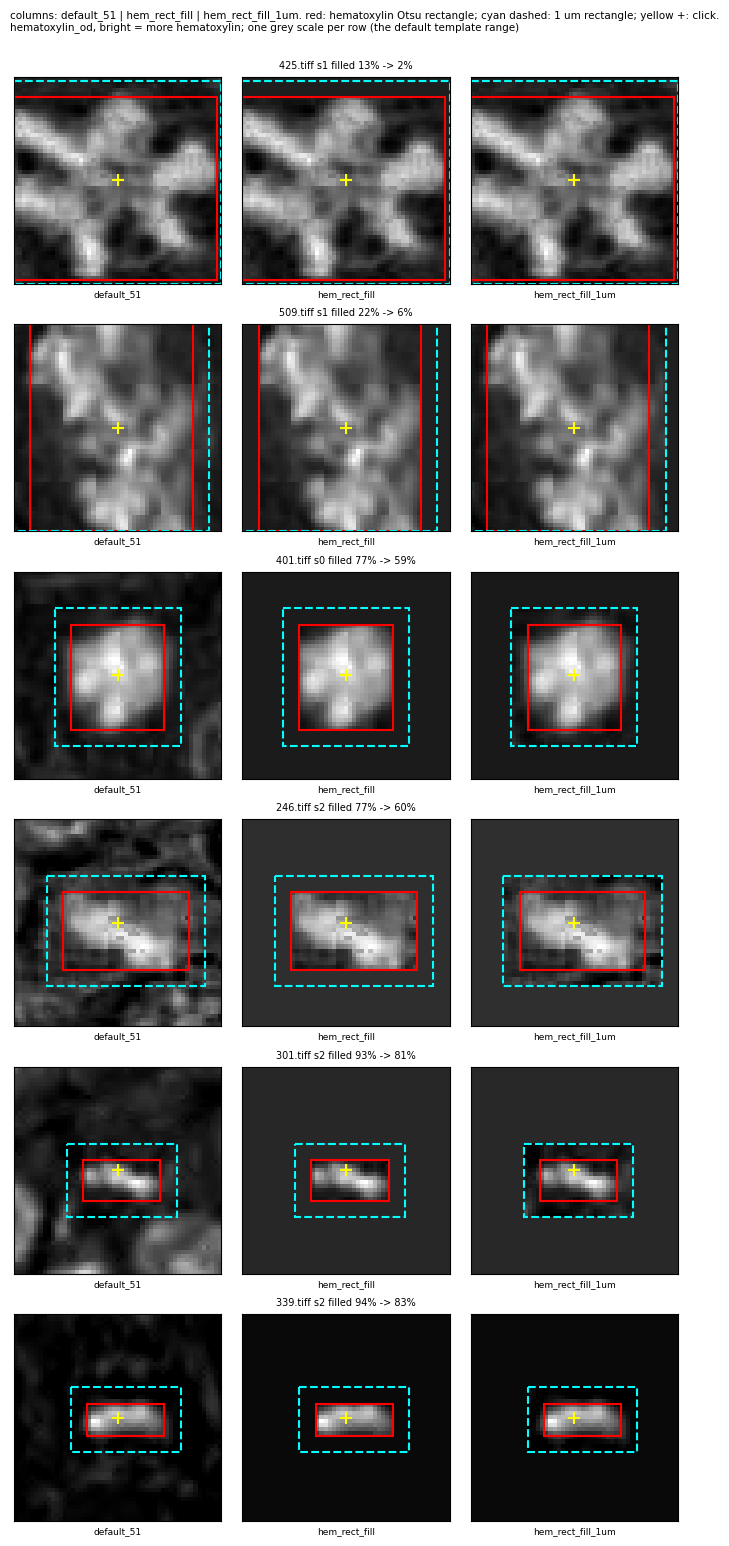

-> hemrectfill1um_49roi3seed_templates.png  (sorted positions [0, 1, 72, 73, 145, 146] of 147 clicks by filled_share_1um)


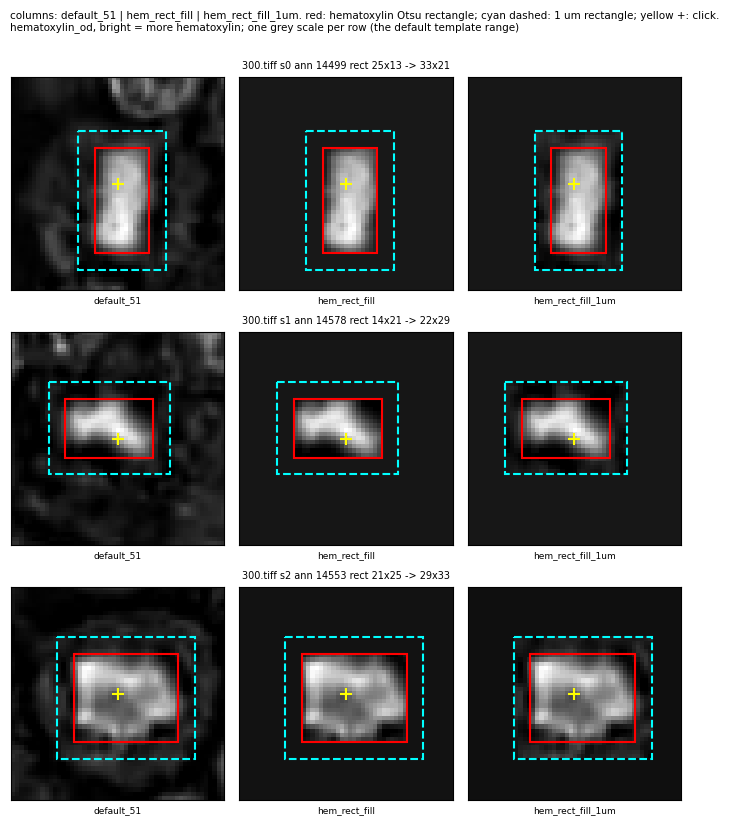

-> hemrectfill1um_300_templates.png  (3 clicks)


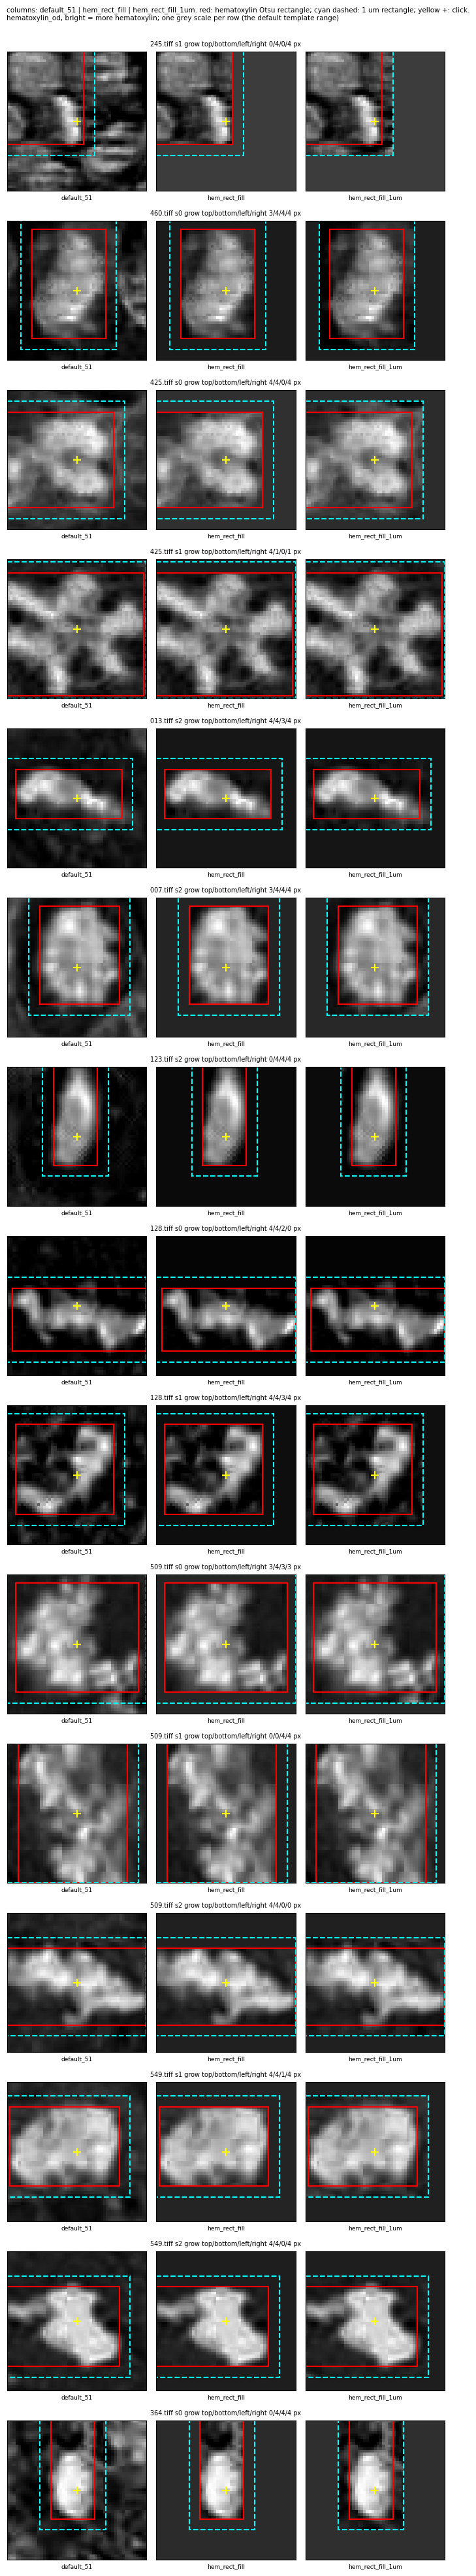

-> hemrectfill1um_clipped_edge_templates.png  (15 clicks with a clipped edge)
run loop 54.1 min; notebook 54.4 min


In [9]:
def draw_click(axes, cut, title):
    """
        Draw one click's three templates side by side, each with the hematoxylin rectangle (red) and the 1 um rectangle (cyan).

        axes (np.ndarray): three matplotlib axes, one per arm.
        cut (dict): the click's cut_templates result.
        title (str): the row's title, centred over the middle panel.

        Returns None: draws into axes.
    """
    y0, y1, x0, x1 = cut['rect']
    my0, my1, mx0, mx1 = cut['rect_m']
    vmin, vmax = float(cut['T'].min()), float(cut['T'].max())
    for ax, key, arm in zip(axes, ('T', 'F0', 'Fm'), ARMS):
        ax.imshow(cut[key], cmap='gray', vmin=vmin, vmax=vmax)
        ax.add_patch(Rectangle((x0 - 0.5, y0 - 0.5), x1 - x0, y1 - y0, fill=False, edgecolor='red', linewidth=1.5))
        ax.add_patch(Rectangle((mx0 - 0.5, my0 - 0.5), mx1 - mx0, my1 - my0, fill=False, edgecolor='cyan', linewidth=1.5, linestyle='--'))
        ax.plot(25, 25, marker='+', color='yellow', ms=8, mew=1.5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(arm, fontsize=6.5)
    axes[1].set_title(title, fontsize=7)


LEGEND = 'columns: default_51 | hem_rect_fill | hem_rect_fill_1um. red: hematoxylin Otsu rectangle; cyan dashed: 1 um rectangle; yellow +: click.\nhematoxylin_od, bright = more hematoxylin; one grey scale per row (the default template range)'
table = CLICK_TABLE.assign(_roi_o=CLICK_TABLE['file_name'].map({fn: i for i, fn in enumerate(ROI_ORDER)}))

# Figure 1 -- clicks at the lowest, middle and highest filled share of the 1 um arm
fig_clicks = table.sort_values(['filled_share_1um', '_roi_o', 'seed_index'], kind='mergesort').reset_index(drop=True)
n = len(fig_clicks)
positions = [0, 1, n // 2 - 1, n // 2, n - 2, n - 1]
fig, axes = plt.subplots(6, 3, figsize=(7, 15))
for row_axes, pos in zip(axes, positions):
    c = fig_clicks.iloc[pos]
    draw_click(row_axes, TEMPLATES[(c['file_name'], int(c['seed_index']))], f"{c['file_name']} s{int(c['seed_index'])} filled {c['filled_share']:.0%} -> {c['filled_share_1um']:.0%}")
fig.tight_layout()
fig.suptitle(LEGEND, fontsize=7.5, x=0.02, ha='left', va='bottom', y=1 + 0.15 / fig.get_figheight())
fig.savefig(FIG_PATHS['overview'], dpi=150, bbox_inches='tight')
plt.show()
print(f"-> {FIG_PATHS['overview']}  (sorted positions {positions} of {n} clicks by filled_share_1um)")

# Figure 2 -- the three clicks of the ROI inspected by eye
insp = table[table['file_name'] == INSPECT_ROI].sort_values('seed_index')
fig, axes = plt.subplots(len(insp), 3, figsize=(7, 2.6 * len(insp)), squeeze=False)
for row_axes, (_, c) in zip(axes, insp.iterrows()):
    draw_click(row_axes, TEMPLATES[(c['file_name'], int(c['seed_index']))], f"{c['file_name']} s{int(c['seed_index'])} ann {int(c['seed_ann_id'])} rect {int(c['rect_h'])}x{int(c['rect_w'])} -> {int(c['rectm_h'])}x{int(c['rectm_w'])}")
fig.tight_layout()
fig.suptitle(LEGEND, fontsize=7.5, x=0.02, ha='left', va='bottom', y=1 + 0.15 / fig.get_figheight())
fig.savefig(FIG_PATHS['inspect_roi'], dpi=150, bbox_inches='tight')
plt.show()
print(f"-> {FIG_PATHS['inspect_roi']}  ({len(insp)} clicks)")

# Figure 3 -- every click with an edge clipped at the window border
clip_rows = table[(table[['grow_top', 'grow_bottom', 'grow_left', 'grow_right']] < table[['margin_px']].to_numpy()).any(axis=1)].sort_values(['_roi_o', 'seed_index'])
fig, axes = plt.subplots(len(clip_rows), 3, figsize=(7, 2.6 * len(clip_rows)), squeeze=False)
for row_axes, (_, c) in zip(axes, clip_rows.iterrows()):
    draw_click(row_axes, TEMPLATES[(c['file_name'], int(c['seed_index']))], f"{c['file_name']} s{int(c['seed_index'])} grow top/bottom/left/right {int(c['grow_top'])}/{int(c['grow_bottom'])}/{int(c['grow_left'])}/{int(c['grow_right'])} px")
fig.tight_layout()
fig.suptitle(LEGEND, fontsize=7.5, x=0.02, ha='left', va='bottom', y=1 + 0.15 / fig.get_figheight())
fig.savefig(FIG_PATHS['clipped'], dpi=150, bbox_inches='tight')
plt.show()
print(f"-> {FIG_PATHS['clipped']}  ({len(clip_rows)} clicks with a clipped edge)")
print(f"run loop {RUNTIME_LOOP_MIN:.1f} min; notebook {(time.time() - NB_T0) / 60:.1f} min")

## Results

Every number below is printed by a cell above. "Points" are percentage points of precision. Every delta is `a - b`.

**Reproduction gates (Cells 4 and 8).**
- `default_51`: 147/147 runs reproduce the recorded bbox3way run. That covers `n_peaks`, `n_detections`, `n_self_hits`,
  TP@K, the template SHA-1, and the top-30 `rank`/`cx`/`cy`/`bucket`/`matched_ann_id`/float32 `score`/`od`. `od` is
  bit-exact on 4410/4410 rows.
- `hem_rect_fill`: 147/147 runs reproduce the recorded hemrectfill run on the same fields. `od` is bit-exact on 4410/4410 rows.
- Reproduction pair `hem_rect_fill - default_51`: per-ROI deltas equal the recorded run on 147/147 (ROI, K) rows. All
  25 `delta_stats` columns equal the recorded run, with floats at rtol 1e-12.
- The run loop took 54.1 min for 441 template runs. The median per run was 4.38, 4.28 and 4.35 s by arm, and the max was 71.0 s.

**Checks (Cell 5).**
- *Halt checks, all passed:*
  - every list delivered at least 30 candidates (441/441). `n_detections` is 81-100 for `default_51`, 84-100 for `hem_rect_fill` and 82-100 for `hem_rect_fill_1um`;
  - no NaN `od` and every list is `od`-descending (441/441 each);
  - one row per arm per click (147/147);
  - margin geometry: each edge grew by min(4 px, room to the window border), and the filled pixel counts match (147/147);
  - both filled templates keep the default template's mean (147/147; max gap 2.58e-09).
- *Report checks:*
  - the margin is 4 px on 147/147 clicks;
  - 15/147 clicks have at least one edge clipped at the window border (listed in Cell 5). The tightest is `425.tiff` s1, where 51 px are filled;
  - `n_peaks == 100` on 147/147 runs in every arm;
  - no candidate within one match radius of the click, 147/147 in every arm;
  - `n_self_hits`: `default_51` {0: 2, 1: 145}, `hem_rect_fill` {0: 11, 1: 136}, `hem_rect_fill_1um` {0: 6, 1: 141};
  - per click, `n_detections` for `hem_rect_fill_1um - default_51` ranges from -3 to +16.

**Fill geometry (Cell 6), 147 clicks.**
- The kept rectangle grows from a median 25 x 26 px to 33 x 34 px (height 16-51, width 20-51).
- Filled share drops from a median 0.7735 to 0.5952 (0.0196-0.8339). Per click, the margin lowers filled share by 0.1015-0.2707 (median 0.1753).
- The kept rectangle touches the window edge on 9 clicks for `hem_rect_fill` and 20 for `hem_rect_fill_1um`.

**Pooled precision per arm (Cells 7-8).** Cluster-bootstrap 95% CI over ROIs, unpaired.

| K | `default_51` | `hem_rect_fill` | `hem_rect_fill_1um` |
|---|---|---|---|
| 10 | 0.5694 [0.4932, 0.6435] (837) | 0.5714 [0.4959, 0.6442] (840) | 0.5789 [0.5041, 0.6510] (851) |
| 20 | 0.4969 [0.4238, 0.5690] (1461) | 0.5017 [0.4299, 0.5718] (1475) | 0.5031 [0.4299, 0.5745] (1479) |
| 30 | 0.4331 [0.3635, 0.5032] (1910) | 0.4424 [0.3730, 0.5120] (1951) | 0.4426 [0.3728, 0.5134] (1952) |

TP counts are in brackets after each CI; the denominators are 1470, 2940 and 4410.

**Paired deltas (Cell 8).** 49 ROIs x 3 clicks. W/L/T is on the ROI's delta summed over its 3 clicks. Holm adjusts over
the 6 tests of A and B; the reproduction pair has its own Holm over 3.

| pair | K | delta (pts) | bootstrap 95% CI | t 95% CI | ROI W/L/T | exact p | Holm p | D5 bar | `d5_robustness` |
|---|---|---|---|---|---|---|---|---|---|
| A: `hem_rect_fill_1um - default_51` | 10 | +0.95 | [-0.41, +2.38] | [-0.47, +2.38] | 14/7/28 | 0.227 | 0.872 | not met (14/49) | not met |
| A | 20 | +0.61 | [-0.20, +1.56] | [-0.30, +1.52] | 15/11/23 | 0.218 | 0.872 | not met (15/49) | not met |
| A | 30 | +0.95 | [+0.20, +1.84] | [+0.11, +1.80] | 19/13/17 | 0.0240 | 0.120 | not met (19/49) | not met |
| B: `hem_rect_fill_1um - hem_rect_fill` | 10 | +0.75 | [+0.27, +1.36] | [+0.19, +1.31] | 9/1/39 | 0.0156 | 0.0938 | not met (9/49) | not met |
| B | 20 | +0.14 | [-0.34, +0.58] | [-0.34, +0.61] | 13/8/28 | 0.678 | 1 | not met (13/49) | not met |
| B | 30 | +0.02 | [-0.36, +0.34] | [-0.34, +0.39] | 15/9/25 | 1 | 1 | not met (15/49) | not met |
| reproduction: `hem_rect_fill - default_51` | 10 | +0.20 | [-1.09, +1.56] | [-1.14, +1.55] | 10/9/30 | 0.846 | 1 | not met | not met |
| reproduction | 20 | +0.48 | [-0.51, +1.70] | [-0.66, +1.61] | 19/16/14 | 0.505 | 1 | not met | not met |
| reproduction | 30 | +0.93 | [+0.05, +2.04] | [-0.09, +1.95] | 20/14/15 | 0.0619 | 0.186 | not met | not met |

Descriptive only:
- Click-level W/L/T for A is 23/13/111, 29/26/92 and 39/31/77 at K = 10, 20, 30.
- Click-level W/L/T for B is 12/3/132, 21/16/110 and 22/19/106.
- Per domain, `human neuroendocrine tumor` is the only domain below 0 in A at every K (-0.95, -1.43, -0.79 points).

**How A and B relate.** The two pairs share every click and the same bootstrap indices, so they are not independent.
- At K = 30 the margin adds 1 TP over the tight crop (1952 vs 1951). A's K = 30 result is therefore essentially the
  gain the tight crop already had over `default_51` (reproduction row: +0.93 points [+0.05, +2.04], with the t
  interval including 0). Here it is measured again with a narrower interval, not as a second, separate finding.
- The margin itself changes precision measurably only at K = 10, where B gains +11 TP.

**Reading, by Cell 0's rules.**

*A: `hem_rect_fill_1um - default_51`.*
- **K = 10:** the bootstrap CI includes 0, so no difference is detected. The bound is [-0.41, +2.38] points (t [-0.47, +2.38], exact p 0.227, Holm 0.872, W/L/T 14/7/28, D5 not met).
- **K = 20:** the bootstrap CI includes 0, so no difference is detected. The bound is [-0.20, +1.56] points (t [-0.30, +1.52], exact p 0.218, Holm 0.872, W/L/T 15/11/23, D5 not met).
- **K = 30:** the bootstrap CI excludes 0 and the delta is > 0. By the rule, `hem_rect_fill_1um` has higher precision@30
  than `default_51`, by +0.95 points [+0.20, +1.84]. The t interval also excludes 0 ([+0.11, +1.80]) and the exact
  p is 0.0240. But the Holm p over the 6 tests is 0.120, and only 19 of 49 ROIs go up (13 down, 17 tied). So the D5
  bar is not met, and `d5_robustness` labels the row "not met".

*B: `hem_rect_fill_1um - hem_rect_fill`.*
- **K = 10:** the bootstrap CI excludes 0 and the delta is > 0. By the rule, adding the 1 um margin gives higher
  precision@10 than the tight crop, by +0.75 points [+0.27, +1.36]. The t interval also excludes 0 ([+0.19, +1.31])
  and the exact p is 0.0156. But the Holm p is 0.0938, and 39 of 49 ROIs are tied (9 up, 1 down), so the D5 bar is
  not met and `d5_robustness` is "not met". Of the 10 ROIs whose delta is not 0, 9 favour the margin.
- **K = 20:** the bootstrap CI includes 0, so no difference is detected. The bound is [-0.34, +0.58] points (exact p 0.678, Holm 1, W/L/T 13/8/28).
- **K = 30:** the bootstrap CI includes 0, so no difference is detected. The bound is [-0.36, +0.34] points (exact p 1, Holm 1, W/L/T 15/9/25).

Descriptive, per click (Cells 4 and 7):
- **`300.tiff`:** the summed TP@10/20/30 is (27, 56, 81) for `default_51`, (27, 54, 79) for `hem_rect_fill` and (29, 56, 81) for `hem_rect_fill_1um`.
- **`291.tiff` s0:** TP@30 is 5, 16 and 13 across the three arms.

This run does not measure why any of these changes happen.